# Modelo CNN - EfficientNet-B0

## Activar GPU NVIDIA

In [1]:
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
import torch

print(torch.__version__)               # Debe contener "cu121" o similar, NO "cpu"
print(torch.cuda.is_available())       # Debe imprimir: True
print(torch.cuda.get_device_name(0))   # Debe imprimir el nombre de tu GPU, ej: "NVIDIA GeForce RTX 3060"
device = (
    "cuda"  if torch.cuda.is_available() else
    "mps"   if torch.backends.mps.is_available() else  # Apple Silicon
    "cpu"
)
print(f"Usando dispositivo: {device}")
# Output esperado en tu caso → "Usando dispositivo: cuda"

2.5.1
True
NVIDIA GeForce RTX 4070 Laptop GPU
Usando dispositivo: cuda


## 1. Imports y configuración global

In [2]:
# ============================================================
# 1. IMPORTS Y CONFIGURACIÓN GLOBAL
# ============================================================

# --- Librerías estándar ---
import pathlib

# --- Data Science ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- PyTorch core ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- Torchvision ---
import torchvision.transforms as transforms
import torchvision.models as models

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- PIL ---
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Evitar crashes con imágenes corruptas
Image.MAX_IMAGE_PIXELS = None           # Suprimir DecompressionBombWarning

# ============================================================
# CONSTANTES GLOBALES
# ============================================================

# Rutas
# ✅ IMG_DIR apunta ahora a las imágenes ya pre-procesadas (224×224)
# El script 00_resize_images.py ya hizo el Resize(256)+CenterCrop(224)
SYNC_CSV  = pathlib.Path("../data/listingV5_PriceCapID.csv", dtype={'id': 'Int64'})
IMG_DIR   = pathlib.Path("../data/Front_Images_224/")
MODEL_DIR = pathlib.Path("../models/")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparámetros
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 500
LR          = 1e-3
RANDOM_SEED = 42

# Estadísticas de normalización ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibilidad
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Diagnóstico
print("=" * 55)
print("  SmartHost Analytics — Fase 3: CNN Visual")
print("=" * 55)
print(f"  PyTorch versión : {torch.__version__}")
print(f"  Dispositivo     : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU             : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  ⚠️  Sin GPU — el entrenamiento será más lento en CPU.")
print(f"  IMG_SIZE        : {IMG_SIZE}x{IMG_SIZE} px")
print(f"  BATCH_SIZE      : {BATCH_SIZE}")
print(f"  NUM_EPOCHS      : {NUM_EPOCHS}")
print(f"  Learning Rate   : {LR}")
print("=" * 55)

  SmartHost Analytics — Fase 3: CNN Visual
  PyTorch versión : 2.5.1
  Dispositivo     : cuda
  GPU             : NVIDIA GeForce RTX 4070 Laptop GPU
  VRAM disponible : 8.6 GB
  IMG_SIZE        : 224x224 px
  BATCH_SIZE      : 32
  NUM_EPOCHS      : 500
  Learning Rate   : 0.001


C:\Users\david\AppData\Local\Temp\ipykernel_20048\1948430365.py:38: DeprecationWarning: support for supplying keyword arguments to pathlib.PurePath is deprecated and scheduled for removal in Python 3.14
  SYNC_CSV  = pathlib.Path("../data/listingV5_PriceCapID.csv", dtype={'id': 'Int64'})


## 1.1. Sincronización Dataset (CSV ↔ Imágenes)

✅ CSV cargado: 5,667 filas, 32 columnas
✅ Verificación OK — los 5,667 IDs del CSV tienen imagen en disco.

📊 Estadísticas de precio:
count    5667.00
mean      111.77
std        61.67
min        18.00
25%        75.00
50%        98.00
75%       132.00
max       450.00
Name: price, dtype: float64


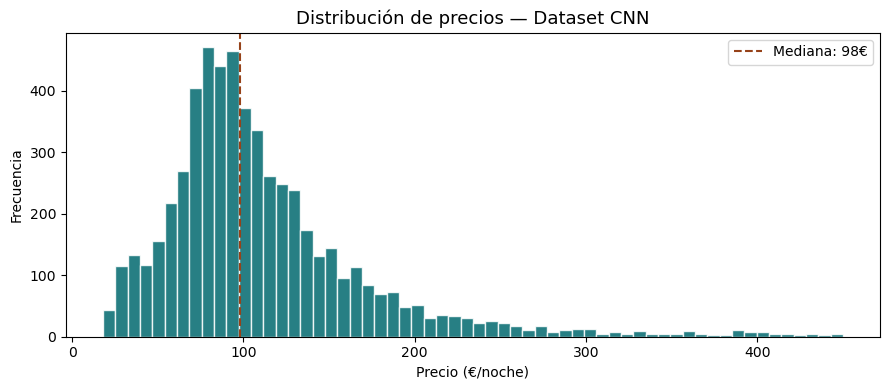

In [3]:
# ============================================================
# 1.1 — CARGA Y VERIFICACIÓN DEL CSV SINCRONIZADO
# ============================================================
# Las imágenes ya están pre-procesadas y sincronizadas con el CSV
# por el script 00_resize_images.py — no hace falta re-sincronizar.
# Solo verificamos que todo encaja antes de entrenar.

df_sync = pd.read_csv(SYNC_CSV)

print(f"✅ CSV cargado: {len(df_sync):,} filas, {len(df_sync.columns)} columnas")

# Verificación rápida: comprobar que cada ID del CSV tiene su imagen en disco
ids_csv        = set(df_sync["id"].astype(int).tolist())
# Construcción robusta del inventario de imágenes
ids_en_disco = set()
nombres_a_id = {}  # mapa: id_int → path real del archivo

for f in IMG_DIR.glob("*.jpg"):
    stem = f.stem  # ej: "12345" o "5.098e+17"
    try:
        id_int = int(float(stem))  # convierte ambos formatos al mismo int
        ids_en_disco.add(id_int)
        nombres_a_id[id_int] = f
    except ValueError:
        pass

ids_csv = set(df_sync["id"].astype("Int64").tolist())
ids_sin_imagen = ids_csv - ids_en_disco

if ids_sin_imagen:
    print(f"⚠️  AVISO: {len(ids_sin_imagen)} IDs en el CSV no tienen imagen en {IMG_DIR}")
    print(f"   Vuelve a ejecutar 00_resize_images.py para regenerarlas.")
else:
    print(f"✅ Verificación OK — los {len(ids_csv):,} IDs del CSV tienen imagen en disco.")

print(f"\n📊 Estadísticas de precio:")
print(df_sync["price"].describe().round(2))

# Distribución de precios
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_sync["price"], bins=60, color="#01696f", edgecolor="white", alpha=0.85)
ax.set_title("Distribución de precios — Dataset CNN", fontsize=13)
ax.set_xlabel("Precio (€/noche)")
ax.set_ylabel("Frecuencia")
ax.axvline(df_sync["price"].median(), color="#964219", linestyle="--",
            label=f'Mediana: {df_sync["price"].median():.0f}€')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Dataset personalizado — AirbnbImageDataset

In [4]:
class AirbnbImageDataset(Dataset):
    """
    Devuelve (tensor [3,224,224], precio_float) por cada apartamento.
    Las imágenes en IMG_DIR ya son 224×224 (pre-procesadas offline).
    """
    def __init__(self, dataframe, imgdir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.imgdir    = pathlib.Path(imgdir)
        self.transform = transform

        # Mapa id_int → path real del archivo
        self.nombres = {}
        for f in self.imgdir.glob("*.jpg"):
            try:
                id_int = int(float(f.stem))
                self.nombres[id_int] = f
            except ValueError:
                pass

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        id_int = int(float(row["id"]))
        precio = float(row["price"])

        img_path = self.nombres[id_int]
        img      = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(precio, dtype=torch.float32)


print("✅  Clase AirbnbImageDataset definida.")
print(f"   Cada __getitem__ devuelve → Tensor[3, {IMG_SIZE}, {IMG_SIZE}], precio(float)")


✅  Clase AirbnbImageDataset definida.
   Cada __getitem__ devuelve → Tensor[3, 224, 224], precio(float)


## 2.2. Pipelines de transformación

**EfficientNet-B0 mejora** respecto a MobileNetV2 con augmentation más rico en train.

In [5]:
# ════════════════════════════════════════════════════════════════════════════
#  PIPELINE TRAIN  (augmentation más agresivo que el notebook de MobileNetV2)
# ════════════════════════════════════════════════════════════════════════════
transform_train = transforms.Compose([
    # --- Data Augmentation (solo train) ---
    transforms.RandomHorizontalFlip(p=0.5),         # espejo horizontal
    transforms.RandomRotation(degrees=10),           # rotación leve ±10°
    transforms.ColorJitter(
        brightness=0.3,                              # variaciones de iluminación
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),  # perspectiva leve
    # --- Tensor + Normalización ImageNet ---
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ════════════════════════════════════════════════════════════════════════════
#  PIPELINE VAL/TEST  (determinista, sin augmentation)
# ════════════════════════════════════════════════════════════════════════════
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅  Pipelines definidos.")
print("\n[TRAIN]")
for i, t in enumerate(transform_train.transforms):
    marker = "  ← solo train" if "Flip" in type(t).__name__ or "Rotation" in type(t).__name__ \
             or "Jitter" in type(t).__name__ or "Perspective" in type(t).__name__ else ""
    print(f"  {i+1}. {type(t).__name__}{marker}")
print("\n[VAL]")
for i, t in enumerate(transform_val.transforms):
    print(f"  {i+1}. {type(t).__name__}")


✅  Pipelines definidos.

[TRAIN]
  1. RandomHorizontalFlip  ← solo train
  2. RandomRotation  ← solo train
  3. ColorJitter  ← solo train
  4. RandomPerspective  ← solo train
  5. ToTensor
  6. Normalize

[VAL]
  1. ToTensor
  2. Normalize


## 2.3. Split Train/Val y DataLoaders

In [6]:
df_train, df_val = train_test_split(
    df_sync,
    test_size=0.20,
    random_state=RANDOM_SEED,
)

dataset_train = AirbnbImageDataset(df_train, IMG_DIR, transform=transform_train)
dataset_val   = AirbnbImageDataset(df_val,   IMG_DIR, transform=transform_val)

loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
loader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("═" * 55)
print("  RESUMEN DE SPLITS Y DATALOADERS")
print("═" * 55)
print(f"  Total sync       : {len(df_sync):,}")
print(f"  Train            : {len(dataset_train):,} imágenes  ({len(loader_train)} batches)")
print(f"  Val              : {len(dataset_val):,} imágenes  ({len(loader_val)} batches)")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  pin_memory       : True  (GPU activa)")
print("═" * 55)


═══════════════════════════════════════════════════════
  RESUMEN DE SPLITS Y DATALOADERS
═══════════════════════════════════════════════════════
  Total sync       : 5,667
  Train            : 4,533 imágenes  (142 batches)
  Val              : 1,134 imágenes  (36 batches)
  Batch size       : 32
  pin_memory       : True  (GPU activa)
═══════════════════════════════════════════════════════


## 2.4. Sanity Check del batch

Shape del batch : torch.Size([32, 3, 224, 224])  (batch, canales, alto, ancho)
Precios (primeros 8) : [120. 111. 114. 111. 147. 122.  81. 181.] €/noche
min=30  max=334  media=118


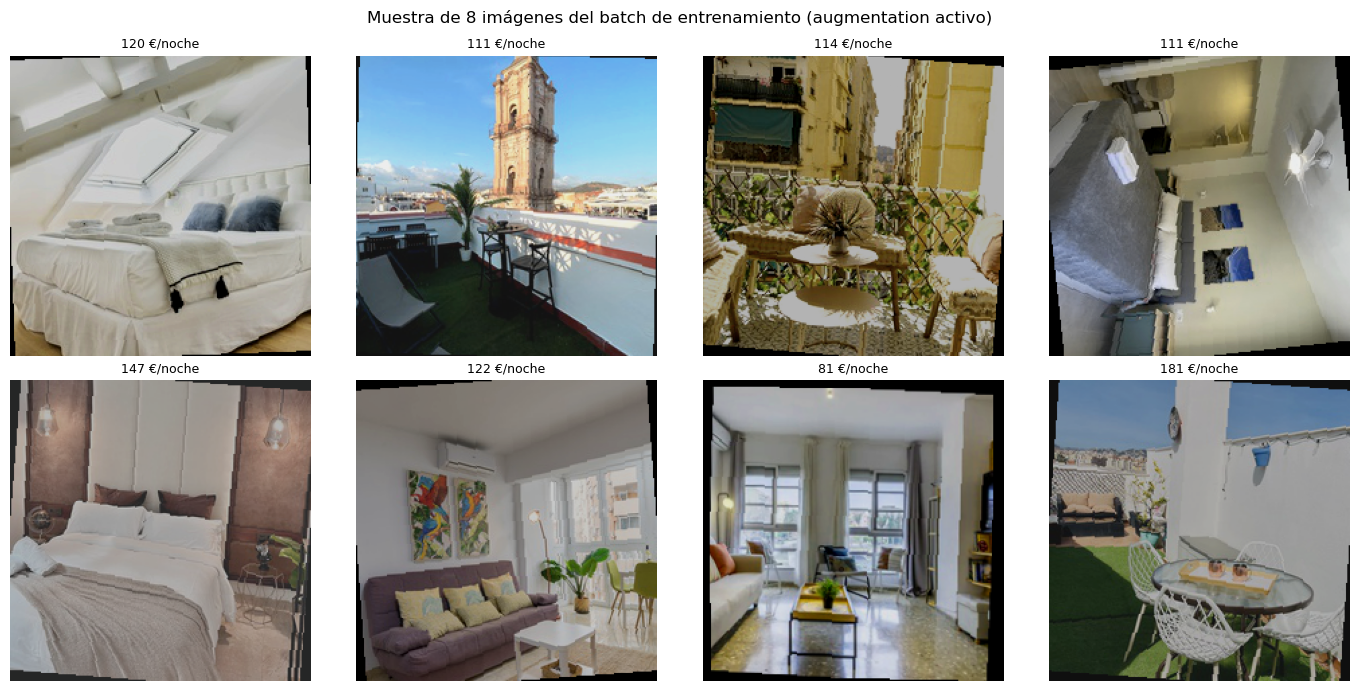

In [7]:
imgs_batch, precios_batch = next(iter(loader_train))
print(f"Shape del batch : {imgs_batch.shape}  (batch, canales, alto, ancho)")
print(f"Precios (primeros 8) : {precios_batch[:8].numpy().round(0)} €/noche")
print(f"min={precios_batch.min():.0f}  max={precios_batch.max():.0f}  media={precios_batch.mean():.0f}")

# Visualizar 8 imágenes desnormalizadas
inv_mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
inv_std  = torch.tensor(IMAGENET_STD).view(3,1,1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = imgs_batch[i].cpu() * inv_std + inv_mean
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    ax.set_title(f"{precios_batch[i]:.0f} €/noche", fontsize=9)
    ax.axis("off")
plt.suptitle("Muestra de 8 imágenes del batch de entrenamiento (augmentation activo)", fontsize=12)
plt.tight_layout()
plt.show()


## 3. Arquitectura — Transfer Learning con EfficientNet-B0

El módulo **Squeeze-and-Excitation (SE)** recalibra canales aprendiendo qué características son más relevantes — ideal para distinguir lujo y modernidad en interiores.

In [8]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# ── 1. Cargar backbone preentrenado en ImageNet ───────────────────────────────
backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# ── 2. Inspeccionar la cabeza original ───────────────────────────────────────
print("Cabeza original de EfficientNet-B0:")
print(backbone.classifier)
print(f"\n  in_features de la última capa: {backbone.classifier[1].in_features}")

# ── 3. CONGELAR todas las capas del backbone (Fase Warm-up) ──────────────────
for param in backbone.features.parameters():
    param.requires_grad = False

# ── 4. SUSTITUIR la cabeza: 1000 clases → 1 número (precio) ─────────────────
IN_FEATURES = backbone.classifier[1].in_features   # 1 280

backbone.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(IN_FEATURES, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(256, 1),
)

model = backbone.to(DEVICE)

# ── 5. Diagnóstico de parámetros ─────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print("\n" + "═"*55)
print("  ARQUITECTURA EfficientNet-B0 (cabeza regresión)")
print("═"*55)
print(f"  Parámetros totales        : {total_params:>10,}")
print(f"  Parámetros ENTRENABLES    : {trainable_params:>10,}  (solo cabeza)")
print(f"  Parámetros CONGELADOS     : {frozen_params:>10,}  (backbone ImageNet)")
print("═"*55)
print("\nNueva cabeza:")
print(model.classifier)


Cabeza original de EfficientNet-B0:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

  in_features de la última capa: 1280

═══════════════════════════════════════════════════════
  ARQUITECTURA EfficientNet-B0 (cabeza regresión)
═══════════════════════════════════════════════════════
  Parámetros totales        :  4,335,741
  Parámetros ENTRENABLES    :    328,193  (solo cabeza)
  Parámetros CONGELADOS     :  4,007,548  (backbone ImageNet)
═══════════════════════════════════════════════════════

Nueva cabeza:
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=1, bias=True)
)


## 4. Loss Function, Optimizer y Scheduler

In [9]:
import torch.optim as optim

# ── Loss: MSE (igual que MobileNetV2 para comparación justa) ─────────────────
criterion = nn.MSELoss()

# ── Optimizer: solo cabeza al inicio (backbone congelado) ────────────────────
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4,
)

# ── Scheduler: ReduceLROnPlateau (idéntico al notebook MobileNetV2) ───────────
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,          # LR × 0.5 al no mejorar
    patience=5,
    min_lr=1e-6,
)

print("✅  Configuración de entrenamiento:")
print(f"   Criterion  : {criterion.__class__.__name__}")
print(f"   Optimizer  : {optimizer.__class__.__name__}  (lr={LR}, wd=1e-4)")
print(f"   Scheduler  : ReduceLROnPlateau  (patience=5, factor=0.5, min_lr=1e-6)")


✅  Configuración de entrenamiento:
   Criterion  : MSELoss
   Optimizer  : Adam  (lr=0.001, wd=1e-4)
   Scheduler  : ReduceLROnPlateau  (patience=5, factor=0.5, min_lr=1e-6)


## 5. Funciones auxiliares — train_epoch / eval_epoch

In [ ]:
import tqdm


def train_epoch(model, loader, criterion, optimizer, device):
    """Una epoch completa de entrenamiento. Devuelve (mse, mae)."""
    model.train()
    total_mse, total_mae, n = 0.0, 0.0, 0

    for imgs, precios in loader:
        imgs    = imgs.to(device, non_blocking=True)
        precios = precios.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(imgs).squeeze(1)
        loss  = criterion(preds, precios)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = precios.size(0)
        total_mse += loss.item() * bs
        total_mae += (preds - precios).abs().sum().item()
        n         += bs

    return total_mse / n, total_mae / n


def eval_epoch(model, loader, criterion, device):
    """Evaluación sobre val/test. Devuelve (mse, mae, rmse, r2)."""
    model.eval()
    total_mse, total_mae, n = 0.0, 0.0, 0
    all_preds, all_true     = [], []

    with torch.no_grad():
        for imgs, precios in loader:
            imgs    = imgs.to(device, non_blocking=True)
            precios = precios.to(device, non_blocking=True)

            preds = model(imgs).squeeze(1)
            loss  = criterion(preds, precios)

            bs = precios.size(0)
            total_mse += loss.item() * bs
            total_mae += (preds - precios).abs().sum().item()
            n         += bs

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(precios.cpu().numpy())

    mse  = total_mse / n
    mae  = total_mae / n
    rmse = np.sqrt(mse)
    r2   = r2_score(all_true, all_preds)
    return mse, mae, rmse, r2

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_mse, total_mae, n = 0.0, 0.0, 0

    pbar = tqdm(loader, desc="  Train", leave=False, unit="batch",
                bar_format="{l_bar}{bar:20}{r_bar}")
    for imgs, precios in pbar:
        imgs    = imgs.to(device, non_blocking=True)
        precios = precios.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(imgs).squeeze(1)
        loss  = criterion(preds, precios)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = precios.size(0)
        total_mse += loss.item() * bs
        total_mae += (preds - precios).abs().sum().item()
        n         += bs

        pbar.set_postfix({"MSE": f"{total_mse/n:.1f}", "MAE": f"{total_mae/n:.2f}€"})

    return total_mse / n, total_mae / n


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_mse, total_mae, n = 0.0, 0.0, 0
    all_preds, all_true     = [], []

    pbar = tqdm(loader, desc="  Val  ", leave=False, unit="batch",
                bar_format="{l_bar}{bar:20}{r_bar}")
    with torch.no_grad():
        for imgs, precios in pbar:
            imgs    = imgs.to(device, non_blocking=True)
            precios = precios.to(device, non_blocking=True)

            preds = model(imgs).squeeze(1)
            loss  = criterion(preds, precios)

            bs = precios.size(0)
            total_mse += loss.item() * bs
            total_mae += (preds - precios).abs().sum().item()
            n         += bs

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(precios.cpu().numpy())

            pbar.set_postfix({"MSE": f"{total_mse/n:.1f}", "MAE": f"{total_mae/n:.2f}€"})

    mse  = total_mse / n
    mae  = total_mae / n
    rmse = np.sqrt(mse)
    r2   = r2_score(all_true, all_preds)
    return mse, mae, rmse, r2
    


print("✅  Funciones train_epoch() y eval_epoch() definidas.")


✅  Funciones train_epoch() y eval_epoch() definidas.


## 6. Early Stopping

In [ ]:
import copy


class EarlyStopping:
    """
    Detiene el entrenamiento si Val MAE no mejora en `patience` epochs.
    Guarda automáticamente los mejores pesos en MODEL_PATH.
    """
    def __init__(self, patience=30, delta=0.0, model_path=None):
        self.patience   = patience
        self.delta      = delta
        self.model_path = model_path or MODEL_DIR / "efficientnet_b0_best.pt"
        self.best_mae   = float("inf")
        self.counter    = 0
        self.best_weights = None

    def step(self, val_mae, model):
        if val_mae < self.best_mae - self.delta:
            self.best_mae     = val_mae
            self.counter      = 0
            self.best_weights = copy.deepcopy(model.state_dict())
            torch.save(self.best_weights, self.model_path)
            return "best"
        else:
            self.counter += 1
            return f"wait {self.counter}/{self.patience}"

    @property
    def stop(self):
        return self.counter >= self.patience

    def restore(self, model):
        model.load_state_dict(self.best_weights)


early_stop = EarlyStopping(patience=30, model_path=MODEL_DIR / "efficientnet_b0_best.pt")
print(f"✅  EarlyStopping  (patience=30) → guarda en '{early_stop.model_path}'")


✅  EarlyStopping  (patience=15) → guarda en '..\models\efficientnet_b0_best.pt'


## 7. Bucle de entrenamiento principal

### Estrategia de dos fases

| Fase | Epochs | Backbone | LR cabeza | Objetivo |
|---|---|---|---|---|
| **Warm-up** | 1–10 |  Congelado | 1e-3 | Ajustar la nueva cabeza |
| **Fine-tuning** | 11+ |  Últimos 3 bloques | 5e-5 | Especializar en interiores |

In [12]:
import time, copy
from tqdm import tqdm# ════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN DE FASES
# ════════════════════════════════════════════════════════════════════════════
WARMUP_EPOCHS  = 10       # epochs con backbone congelado
UNFREEZE_BLOCK = 5        # descongelar features[5:] tras warm-up
LR_FINETUNE    = 5e-5     # LR para capas descongeladas

# ── Historial ────────────────────────────────────────────────────────────────
history = {k: [] for k in ("tr_mse","tr_mae","va_mse","va_mae","va_rmse","r2","lr")}

# ── Cabecera de tabla ─────────────────────────────────────────────────────────
HEADER = (
    f"{'Ep':>4} | {'Tr.MSE':>8} | {'Tr.MAE':>8} | "
    f"{'Va.MSE':>8} | {'Va.MAE':>8} | {'Va.RMSE':>8} | "
    f"{'R²':>6} | {'LR':>8} | Estado"
)
SEP_LINE = "-" * 105
print(HEADER)
print(SEP_LINE)

t_start = time.time()

epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Entrenamiento", unit="epoch")

for epoch in epoch_bar:

    # ── Descongelado parcial al terminar warm-up ──────────────────────────────
    if epoch == WARMUP_EPOCHS + 1:
        print(f"\n🔓  Epoch {epoch}: Descongelando features[{UNFREEZE_BLOCK}:] del backbone "
                f"con LR_finetune={LR_FINETUNE}\n")
        for layer in model.features[UNFREEZE_BLOCK:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Nuevo optimizer que incluye las capas descongeladas
        optimizer = optim.Adam([
            {"params": model.features[UNFREEZE_BLOCK:].parameters(), "lr": LR_FINETUNE},
            {"params": model.classifier.parameters(),                 "lr": LR_FINETUNE},
        ], weight_decay=1e-4)

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6
        )

    # ── Train ─────────────────────────────────────────────────────────────────
    tr_mse, tr_mae = train_epoch(model, loader_train, criterion, optimizer, DEVICE)

    # ── Val ───────────────────────────────────────────────────────────────────
    va_mse, va_mae, va_rmse, r2 = eval_epoch(model, loader_val, criterion, DEVICE)

    # ── Scheduler ─────────────────────────────────────────────────────────────
    scheduler.step(va_mae)
    current_lr = optimizer.param_groups[0]["lr"]

    # ── Early Stopping ────────────────────────────────────────────────────────
    status = early_stop.step(va_mae, model)
    icon   = "✅ Mejor" if status == "best" else f"⏳ {status}"

    # ── Historial ─────────────────────────────────────────────────────────────
    for k, v in zip(history, [tr_mse, tr_mae, va_mse, va_mae, va_rmse, r2, current_lr]):
        history[k].append(v)

    # ── Print fila ── sustituir el print final por:
    fila = (
        f"{epoch:>4} | {tr_mse:>8.1f} | {tr_mae:>7.2f}€ | "
        f"{va_mse:>8.1f} | {va_mae:>7.2f}€ | {va_rmse:>7.2f}€ | "
        f"{r2:>6.3f} | {current_lr:>8.2e} | {icon}"
    )
    tqdm.write(fila)                          # ← tqdm.write en vez de print
    epoch_bar.set_postfix({                   # ← actualiza la barra externa
        "Val MAE": f"{va_mae:.2f}€",
        "R²": f"{r2:.3f}"
    })

    if early_stop.stop:
        tqdm.write(f"\n🛑  Early Stopping en epoch {epoch} — mejor Val MAE: {early_stop.best_mae:.2f}€")
        break

# ── Restaurar mejores pesos ───────────────────────────────────────────────────
early_stop.restore(model)
best_ep  = history["va_mae"].index(min(history["va_mae"])) + 1
best_r2  = history["r2"][best_ep - 1]
best_tr  = history["tr_mae"][best_ep - 1]
elapsed  = time.time() - t_start

print(f"\n✅  Pesos del mejor modelo restaurados (epoch {best_ep})")
print(f"   Val MAE = {early_stop.best_mae:.2f}€  |  Train MAE = {best_tr:.2f}€  |  Val R² = {best_r2:.3f}")
print(f"   Tiempo total de entrenamiento: {elapsed/60:.1f} min")


  Ep |   Tr.MSE |   Tr.MAE |   Va.MSE |   Va.MAE |  Va.RMSE |     R² |       LR | Estado
---------------------------------------------------------------------------------------------------------


Entrenamiento:   0%|          | 1/500 [00:45<6:22:01, 45.93s/epoch, Val MAE=49.19€, R²=-0.247]

   1 |   7307.8 |   62.61€ |   4926.5 |   49.19€ |   70.19€ | -0.247 | 1.00e-03 | ✅ Mejor


Entrenamiento:   0%|          | 2/500 [01:54<8:10:04, 59.05s/epoch, Val MAE=46.58€, R²=-0.127]

   2 |   4528.5 |   47.26€ |   4450.5 |   46.58€ |   66.71€ | -0.127 | 1.00e-03 | ✅ Mejor


...

  30 |   1111.0 |   24.27€ |   3547.2 |   40.46€ |   59.56€ |  0.102 | 1.25e-05 | ⏳ wait 13/15


Entrenamiento:   6%|▌         | 31/500 [44:07<9:38:16, 73.98s/epoch, Val MAE=40.54€, R²=0.099]

  31 |   1128.8 |   24.54€ |   3559.2 |   40.54€ |   59.66€ |  0.099 | 1.25e-05 | ⏳ wait 14/15


Entrenamiento:   6%|▌         | 31/500 [45:19<11:25:38, 87.72s/epoch, Val MAE=40.98€, R²=0.096]


  32 |   1082.1 |   24.25€ |   3569.5 |   40.98€ |   59.75€ |  0.096 | 1.25e-05 | ⏳ wait 15/15

🛑  Early Stopping en epoch 32 — mejor Val MAE: 39.14€

✅  Pesos del mejor modelo restaurados (epoch 17)
   Val MAE = 39.14€  |  Train MAE = 33.66€  |  Val R² = 0.113
   Tiempo total de entrenamiento: 45.3 min


## 8. Curvas de aprendizaje

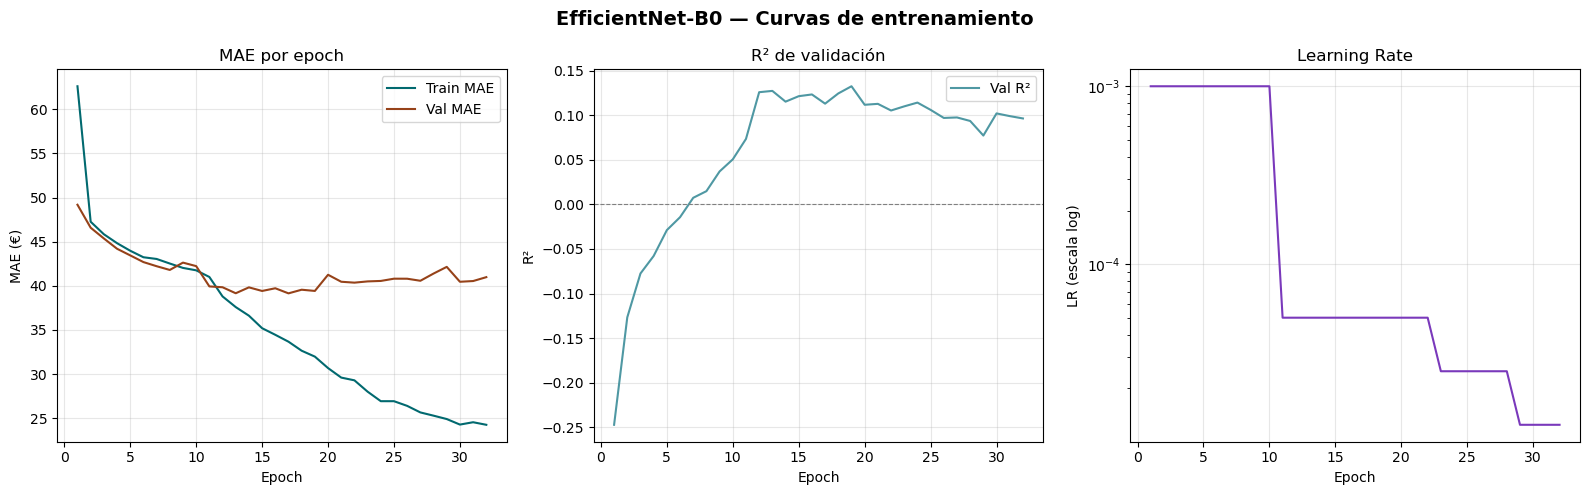

✅  Gráfico guardado en '..\models\efficientnet_b0_training_curves.png'


In [13]:
epochs_range = range(1, len(history["tr_mae"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── MAE ───────────────────────────────────────────────────────────────────────
axes[0].plot(epochs_range, history["tr_mae"], label="Train MAE", color="#01696f")
axes[0].plot(epochs_range, history["va_mae"], label="Val MAE",   color="#964219")
axes[0].set_title("MAE por epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE (€)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── R² ────────────────────────────────────────────────────────────────────────
axes[1].plot(epochs_range, history["r2"], color="#4f98a3", label="Val R²")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("R² de validación")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("R²")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── LR ────────────────────────────────────────────────────────────────────────
axes[2].semilogy(epochs_range, history["lr"], color="#7a39bb")
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR (escala log)")
axes[2].grid(alpha=0.3)

plt.suptitle("EfficientNet-B0 — Curvas de entrenamiento", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "efficientnet_b0_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Gráfico guardado en '{MODEL_DIR / 'efficientnet_b0_training_curves.png'}'")


## 9. Evaluación final y análisis de errores

═══════════════════════════════════════════════════════
  MÉTRICAS FINALES — EfficientNet-B0
═══════════════════════════════════════════════════════
  Val MSE  :    3504.04
  Val MAE  :      39.14 €
  Val RMSE :      59.19 €
  Val R²   :      0.113
═══════════════════════════════════════════════════════


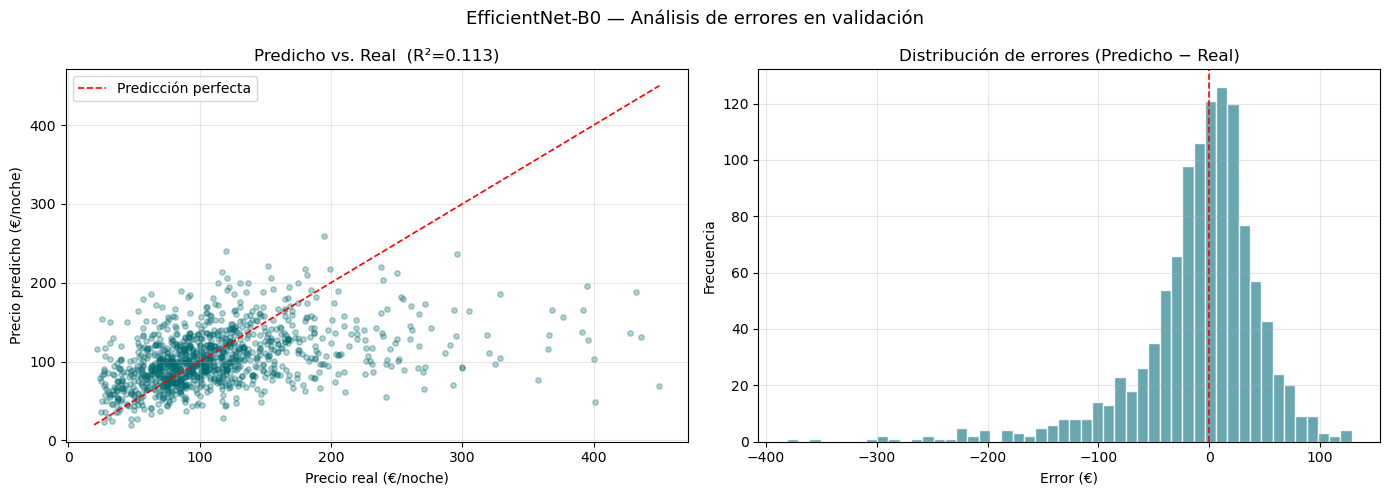

In [14]:
# ── Métricas finales sobre validación ────────────────────────────────────────
va_mse_f, va_mae_f, va_rmse_f, r2_f = eval_epoch(model, loader_val, criterion, DEVICE)

print("═" * 55)
print("  MÉTRICAS FINALES — EfficientNet-B0")
print("═" * 55)
print(f"  Val MSE  : {va_mse_f:>10.2f}")
print(f"  Val MAE  : {va_mae_f:>10.2f} €")
print(f"  Val RMSE : {va_rmse_f:>10.2f} €")
print(f"  Val R²   : {r2_f:>10.3f}")
print("═" * 55)

# ── Scatter: predichos vs. reales ─────────────────────────────────────────────
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, precios in loader_val:
        imgs = imgs.to(DEVICE, non_blocking=True)
        preds = model(imgs).squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(precios.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(all_true, all_preds, alpha=0.3, s=15, color="#01696f")
lims = [min(all_true.min(), all_preds.min()), max(all_true.max(), all_preds.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.2, label="Predicción perfecta")
axes[0].set_title(f"Predicho vs. Real  (R²={r2_f:.3f})")
axes[0].set_xlabel("Precio real (€/noche)")
axes[0].set_ylabel("Precio predicho (€/noche)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribución de errores
errores = all_preds - all_true
axes[1].hist(errores, bins=50, color="#4f98a3", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_title("Distribución de errores (Predicho − Real)")
axes[1].set_xlabel("Error (€)")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.3)

plt.suptitle("EfficientNet-B0 — Análisis de errores en validación", fontsize=13)
plt.tight_layout()
plt.savefig(MODEL_DIR / "efficientnet_b0_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Preparación para la Fusión (Fase 4)

Eliminamos la cabeza de regresión para que la CNN escupa un **vector de 1 280 características visuales** que se concatenará con el Cerebro Tabular.

In [15]:
# ════════════════════════════════════════════════════════════════════════════
#  FEATURE EXTRACTOR — eliminar cabeza de regresión
# ════════════════════════════════════════════════════════════════════════════
class EfficientNetFeatureExtractor(nn.Module):
    """
    EfficientNet-B0 sin cabeza de regresión.
    Devuelve un vector de 1 280 características visuales por imagen.
    Usado en la Fase 4 (fusión con el modelo tabular).
    """
    def __init__(self, trained_model):
        super().__init__()
        self.features = trained_model.features       # backbone
        self.avgpool  = trained_model.avgpool         # GlobalAvgPool → [B, 1280, 1, 1]

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # → [B, 1280]
        return x


feature_extractor = EfficientNetFeatureExtractor(model).to(DEVICE)
feature_extractor.eval()

# ── Test: pasar un batch y ver la forma del vector ────────────────────────────
with torch.no_grad():
    sample_imgs, _ = next(iter(loader_val))
    sample_imgs    = sample_imgs.to(DEVICE)
    features_out   = feature_extractor(sample_imgs)

print("═" * 55)
print("  FEATURE EXTRACTOR — EfficientNet-B0")
print("═" * 55)
print(f"  Input  : {sample_imgs.shape}")
print(f"  Output : {features_out.shape}   ← vector visual por apartamento")
print("═" * 55)

# ── Guardar el extractor ──────────────────────────────────────────────────────
extractor_path = MODEL_DIR / "efficientnet_b0_extractor.pt"
torch.save(feature_extractor.state_dict(), extractor_path)
print(f"\n✅  Feature extractor guardado en '{extractor_path}'")
print("   → Listo para cargar en Fase 4 y concatenar con el Cerebro Tabular.")


═══════════════════════════════════════════════════════
  FEATURE EXTRACTOR — EfficientNet-B0
═══════════════════════════════════════════════════════
  Input  : torch.Size([32, 3, 224, 224])
  Output : torch.Size([32, 1280])   ← vector visual por apartamento
═══════════════════════════════════════════════════════

✅  Feature extractor guardado en '..\models\efficientnet_b0_extractor.pt'
   → Listo para cargar en Fase 4 y concatenar con el Cerebro Tabular.


## 11. Resumen

Ejecuta esta celda **después** de entrenar ambos modelos para ver la comparación directa.

In [ ]:
# ── Cargar métricas de MobileNetV2 si existen ────────────────────────────────
mobilenet_path = MODEL_DIR / "mobilenet_v2_metrics.json"

import json, os

# Guardar métricas de EfficientNet-B0
metrics_effnet = {
    "model":    "EfficientNet-B0",
    "val_mae":  round(float(va_mae_f), 4),
    "val_rmse": round(float(va_rmse_f), 4),
    "val_r2":   round(float(r2_f), 4),
    "best_epoch": best_ep,
}
with open(MODEL_DIR / "efficientnet_b0_metrics.json", "w") as f:
    json.dump(metrics_effnet, f, indent=2)
print("✅  Métricas EfficientNet-B0 guardadas.")


✅  Métricas EfficientNet-B0 guardadas.

════════════════════════════════════════════════════════════
  COMPARATIVA DE MODELOS CNN
════════════════════════════════════════════════════════════
  Modelo                    Val MAE   Val RMSE   Val R²
  --------------------------------------------------------
  EfficientNet-B0            39.14€     59.19€    0.113
  MobileNetV2                     —          —        —  (ejecuta 04_ModeloCNN.ipynb primero)
════════════════════════════════════════════════════════════

💡  El modelo con mayor R² y menor MAE se usará como extractor en Fase 4.
